In [1]:
import pandas as pd
import numpy as np
import shap
import warnings
import joblib
import sys
import psutil
import GPUtil
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, GroupKFold, cross_val_predict, ParameterGrid
from collections import defaultdict
from time import time
from datetime import timedelta
from importlib.metadata import version

# printout of python version
print("="*50, "Python Version", "="*50)
print(f"python version: {sys.version}")
print(f"xgboost:        {version('xgboost')}")
print(f"shap:           {version('shap')}")

# printout of hardware
print("="*50, "Hardware", "="*50)
gpus = GPUtil.getGPUs()
for gpu in gpus:
    print(f"GPU: {gpu.name}")
print(f"CPU cores: {psutil.cpu_count(logical=False)}")
print(f"RAM: {psutil.virtual_memory().total / 1024 / 1024 / 1024 :.2f} GB")

warnings.filterwarnings('ignore')

================================================== Python Version ==================================================
python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
xgboost:        2.1.1
shap:           0.46.0
================================================== Hardware ==================================================
GPU: NVIDIA GeForce RTX 4090
CPU cores: 16
RAM: 63.82 GB


# read data function 

In [2]:
def read_abcd(path, cols, na_values):
    
    df = pd.read_csv(path, sep='\t', index_col='subjectkey', na_values=na_values)
    df = df.drop(df.index[0])
    
    for col in cols:
        df[col] = pd.to_numeric(df[col])
        df = df[cols]

    df = df.reset_index()
    df = df.sort_values(['subjectkey', 'interview_age'])
    df = df.drop_duplicates(subset=['subjectkey'], keep='first')
    df = df.drop(columns=['interview_age'])
    df = df.set_index('subjectkey')
    
    df_show = abcd_ysu02.join(df)
    df_show = df_show.drop(columns=[
        'isip_1d_2',
        'isip_5_2',
        'isip_1b_yn'
    ])
     
    for col in df_show.columns:
        print('{:<30}    n = {:<10}    mean = {:<10.4f}    sum = {:<10.1f}'.\
              format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
    print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))
    
    return df

# y-target variable 

In [3]:
file_abcd_ysu02 = r'D:\gregn\data\ABCD\abcd3\abcd_ysu02.txt'
abcd_ysu02 = pd.read_csv(file_abcd_ysu02, sep='\t', index_col='subjectkey')
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02.index[0])
cols = [
    'interview_age',
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
]

for col in cols:
    abcd_ysu02[col] = pd.to_numeric(abcd_ysu02[col])
    abcd_ysu02 = abcd_ysu02[cols]
    
abcd_ysu02 = abcd_ysu02.reset_index()
abcd_ysu02 = abcd_ysu02.sort_values(['subjectkey', 'interview_age'])
abcd_ysu02 = abcd_ysu02.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_ysu02 = abcd_ysu02.drop(columns=['interview_age'])
abcd_ysu02 = abcd_ysu02.set_index('subjectkey')
    
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 3].index) # drop accidental 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 2].index) # drop furtive 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1b_yn == 0].index) # drop religious 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1d_2 > 10].index) # drop older than 10

abcd_ysu02['isip_1d_2'] = abcd_ysu02['isip_1d_2'].fillna(0)

y = abcd_ysu02['isip_1d_2'].values
y = np.where(y>0, 1, y)

unique, counts = np.unique(y, return_counts=True)

print('number of subjects: {:>10}\n\n[0] never sipped: {:>12}\n[1] sipped by age 10:{:>9}'.\
      format(len(y), counts[0], counts[1]))

number of subjects:      10707

[0] never sipped:         9209
[1] sipped by age 10:     1498


# acspsw03

In [4]:
path = r'D:\gregn\data\ABCD\abcd3\acspsw03.txt'

cols = [
    'interview_age',
    'rel_family_id',

]

na_values = [None]
acspsw03 = read_abcd(path, cols, na_values)

rel_family_id                     n = 10707         mean = 5921.1416     sum = 63397663.0

subjects:     10707
features:         1


# load X features

In [5]:
health = pd.read_csv(r'C:\Users\gregn\jupyter\ABCD_sipping_paper\health\X_features_health.csv')
abcd = pd.merge(health, acspsw03, on='subjectkey', how='left')
X = abcd.drop(columns=['subjectkey', 'rel_family_id'])
X_values = X.values

print('number of features:', X.shape[1])
print('number of subjects:', X.shape[0])
list(X.columns)

number of features: 359
number of subjects: 10707


['ksads_1_845_p',
 'ksads_1_840_p',
 'ksads_1_841_p',
 'ksads_1_842_p',
 'ksads_1_847_p',
 'ksads_1_846_p',
 'ksads_2_837_p',
 'ksads_2_831_p',
 'ksads_2_830_p',
 'ksads_2_833_p',
 'ksads_2_834_p',
 'ksads_2_839_p',
 'ksads_2_838_p',
 'ksads_4_851_p',
 'ksads_4_852_p',
 'ksads_4_826_p',
 'ksads_4_827_p',
 'ksads_4_829_p',
 'ksads_4_828_p',
 'ksads_4_850_p',
 'ksads_4_849_p',
 'ksads_5_906_p',
 'ksads_5_907_p',
 'ksads_5_858_p',
 'ksads_6_859_p',
 'ksads_6_860_p',
 'ksads_7_861_p',
 'ksads_7_909_p',
 'ksads_7_910_p',
 'ksads_7_862_p',
 'ksads_8_864_p',
 'ksads_8_863_p',
 'ksads_8_912_p',
 'ksads_9_868_p',
 'ksads_9_867_p',
 'ksads_10_914_p',
 'ksads_10_913_p',
 'ksads_10_869_p',
 'ksads_10_870_p',
 'ksads_11_917_p',
 'ksads_11_918_p',
 'ksads_11_919_p',
 'ksads_11_920_p',
 'ksads_13_938_p',
 'ksads_13_940_p',
 'ksads_13_942_p',
 'ksads_13_944_p',
 'ksads_13_941_p',
 'ksads_14_856_p',
 'ksads_14_855_p',
 'ksads_14_853_p',
 'ksads_14_854_p',
 'ksads_15_901_p',
 'ksads_15_902_p',
 'ksads_1

# repeated nested cross validation 


Run 1
8 grid search candidates

Runtime for run 1: 0:07:03.491861

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920613288879395

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168161  7.336655    7.336655
1            kbi_y_trans_id    0.133481  5.823605   13.160259
2               pds_skin2_y    0.125321  5.467607   18.627865
3           sleepdisturb4_p    0.101699  4.437020   23.064884
4      physical_activity5

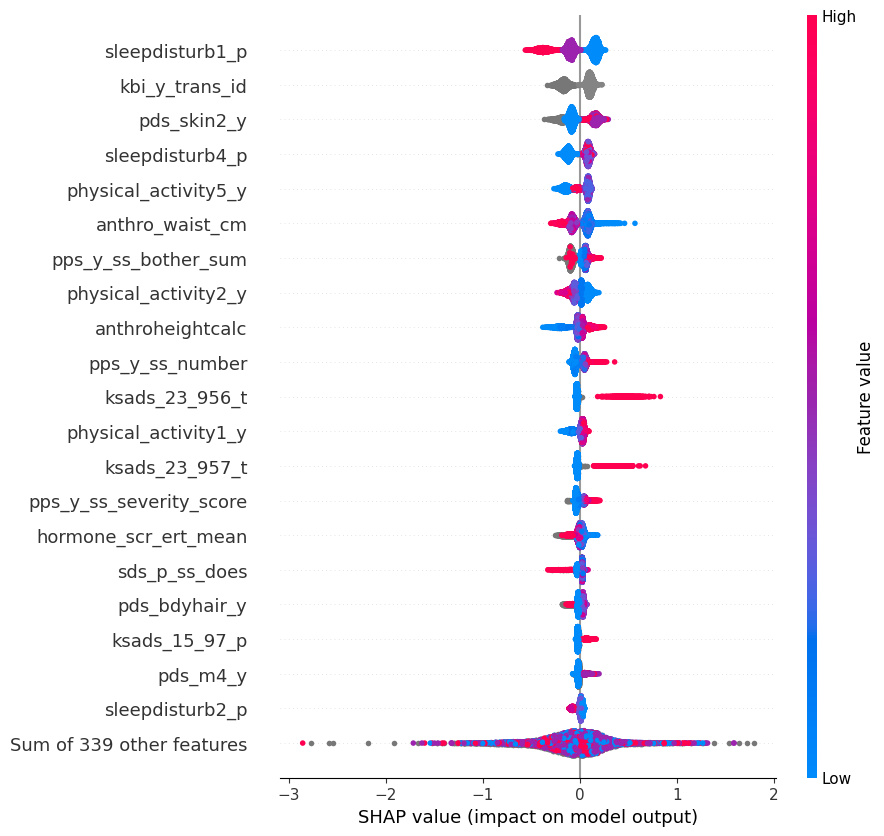


Run 2
8 grid search candidates

Runtime for run 2: 0:07:25.235116

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920610904693604

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168160  7.336637    7.336637
1            kbi_y_trans_id    0.133480  5.823593   13.160229
2               pds_skin2_y    0.125322  5.467635   18.627865
3           sleepdisturb4_p    0.101699  4.437030   23.064896
4      physical_activity5

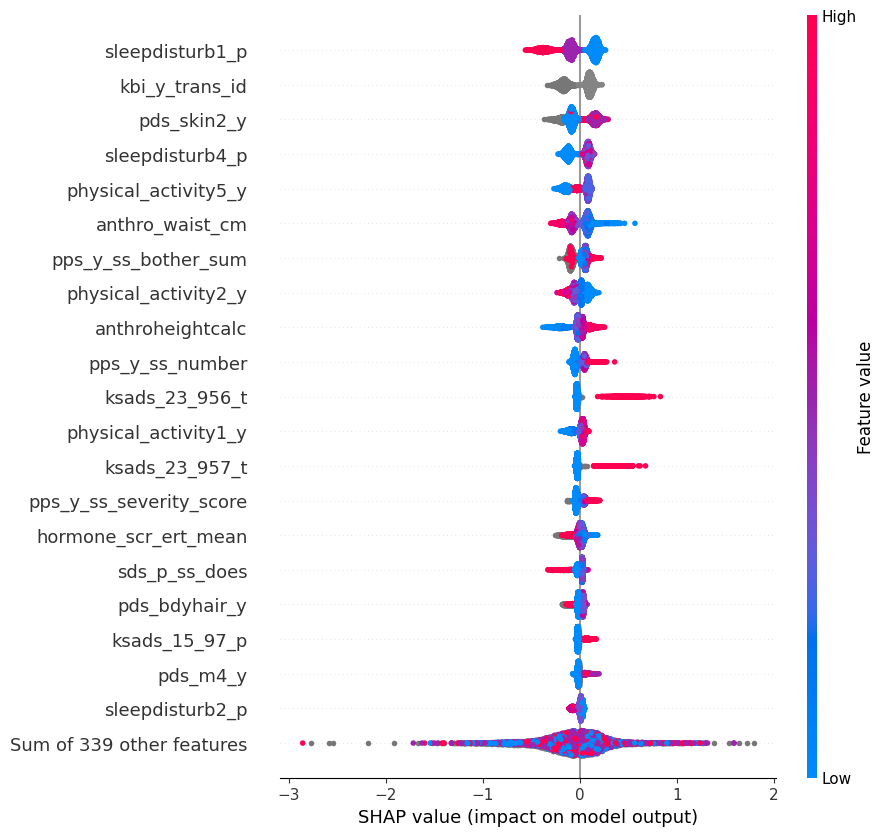


Run 3
8 grid search candidates

Runtime for run 3: 0:07:30.464536

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920613288879395

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168160  7.336649    7.336649
1            kbi_y_trans_id    0.133480  5.823594   13.160244
2               pds_skin2_y    0.125321  5.467618   18.627863
3           sleepdisturb4_p    0.101699  4.437025   23.064888
4      physical_activity5

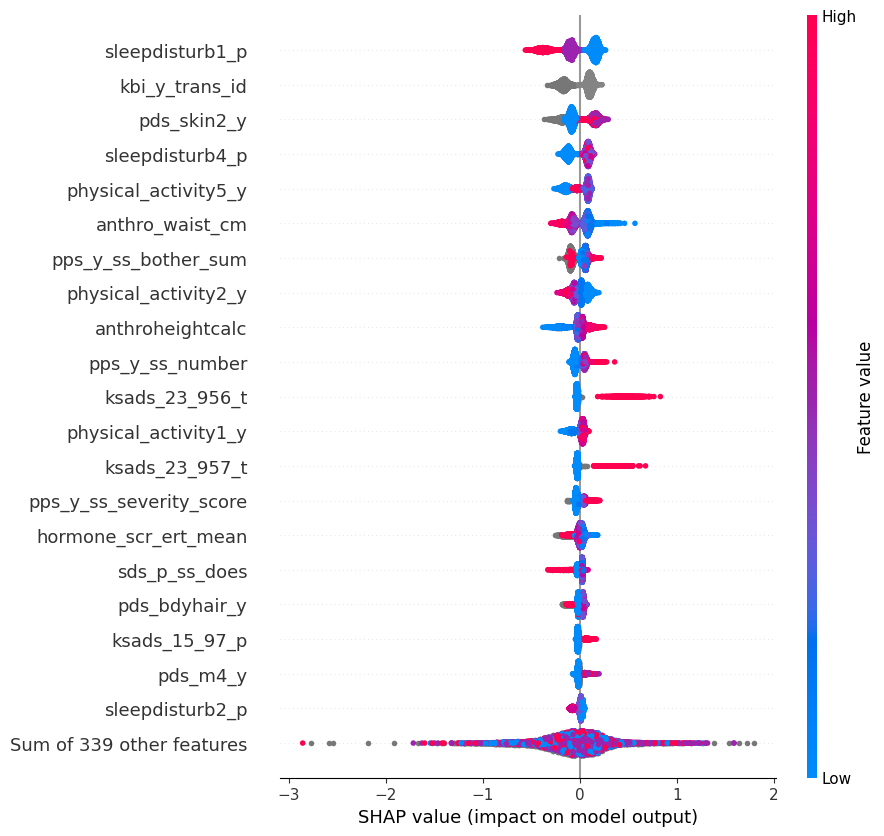


Run 4
8 grid search candidates

Runtime for run 4: 0:07:18.585263

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920613288879395

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168161  7.336661    7.336661
1            kbi_y_trans_id    0.133480  5.823594   13.160255
2               pds_skin2_y    0.125321  5.467630   18.627886
3           sleepdisturb4_p    0.101699  4.437010   23.064896
4      physical_activity5

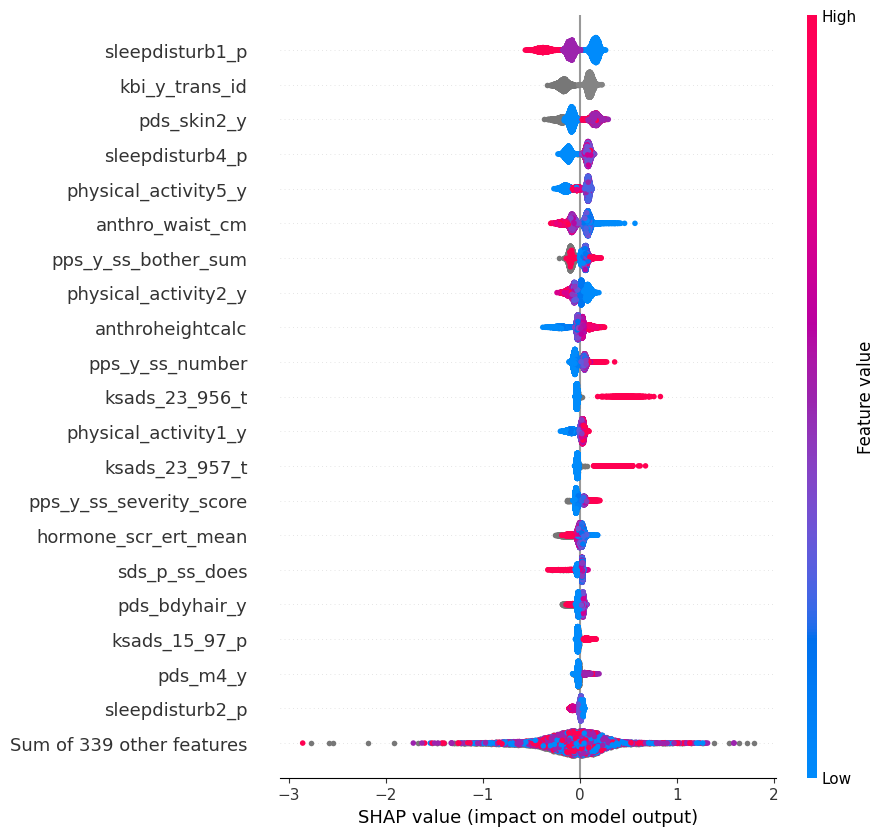


Run 5
8 grid search candidates

Runtime for run 5: 0:07:05.443515

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920618057250977

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168161  7.336654    7.336654
1            kbi_y_trans_id    0.133480  5.823593   13.160246
2               pds_skin2_y    0.125321  5.467614   18.627859
3           sleepdisturb4_p    0.101699  4.437023   23.064882
4      physical_activity5

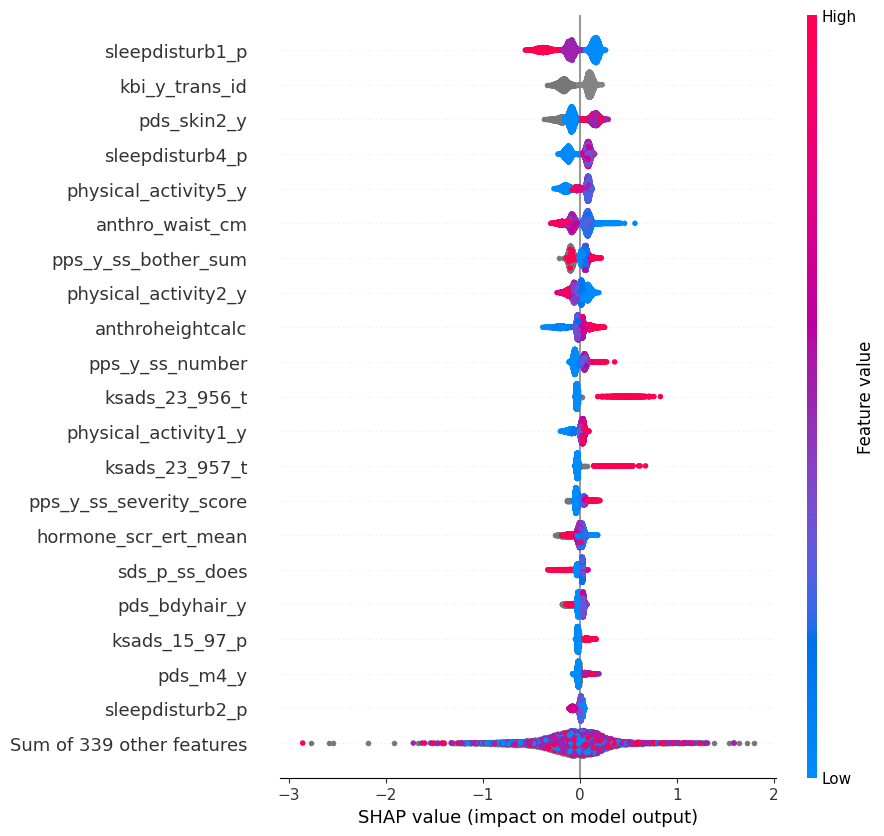


Run 6
8 grid search candidates

Runtime for run 6: 0:07:13.945849

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.292062520980835

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168161  7.336654    7.336654
1            kbi_y_trans_id    0.133481  5.823604   13.160257
2               pds_skin2_y    0.125322  5.467632   18.627890
3           sleepdisturb4_p    0.101699  4.437020   23.064909
4      physical_activity5_

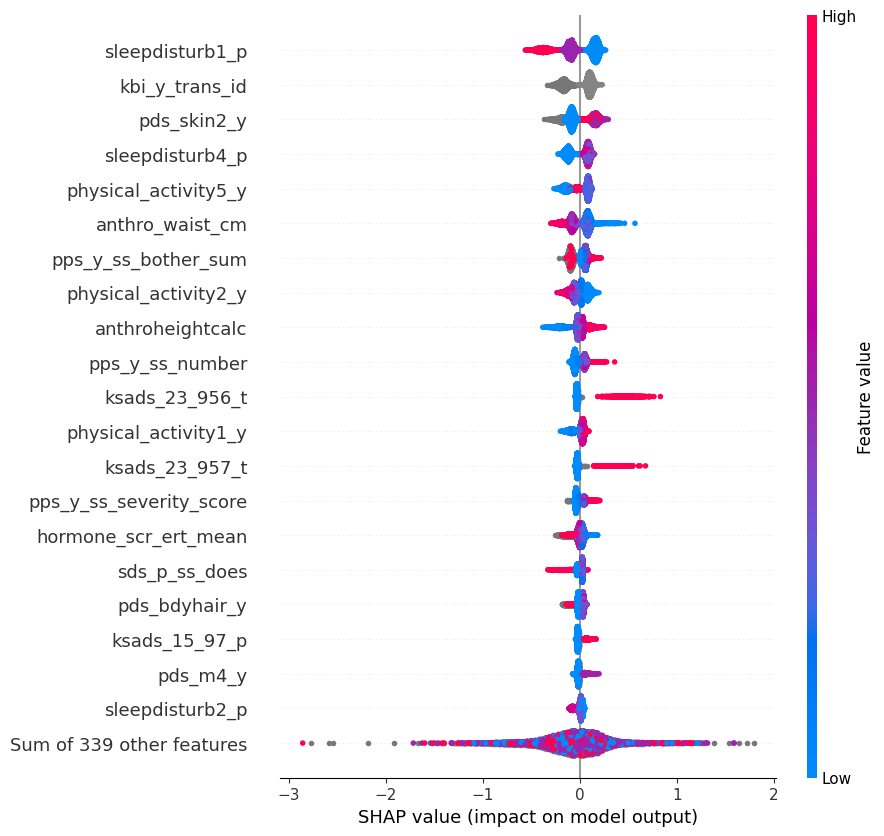


Run 7
8 grid search candidates

Runtime for run 7: 0:07:00.656999

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920613288879395

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168160  7.336632    7.336632
1            kbi_y_trans_id    0.133480  5.823588   13.160220
2               pds_skin2_y    0.125321  5.467630   18.627850
3           sleepdisturb4_p    0.101699  4.437029   23.064878
4      physical_activity5

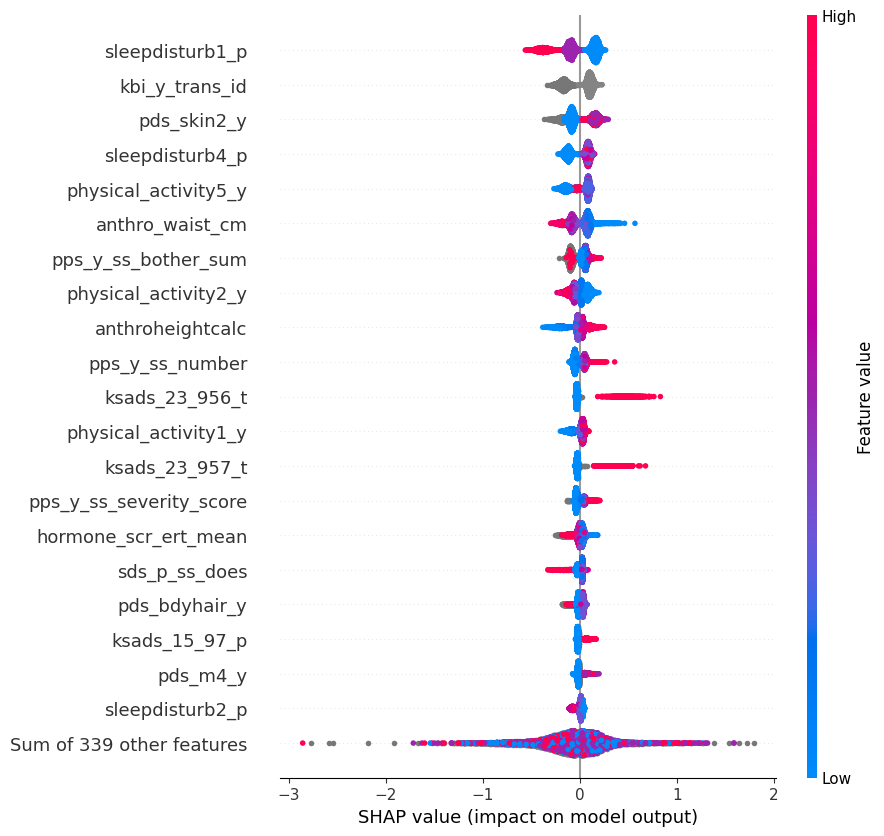


Run 8
8 grid search candidates

Runtime for run 8: 0:07:00.794231

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920618057250977

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168161  7.336651    7.336651
1            kbi_y_trans_id    0.133481  5.823601   13.160252
2               pds_skin2_y    0.125321  5.467623   18.627874
3           sleepdisturb4_p    0.101699  4.437013   23.064888
4      physical_activity5

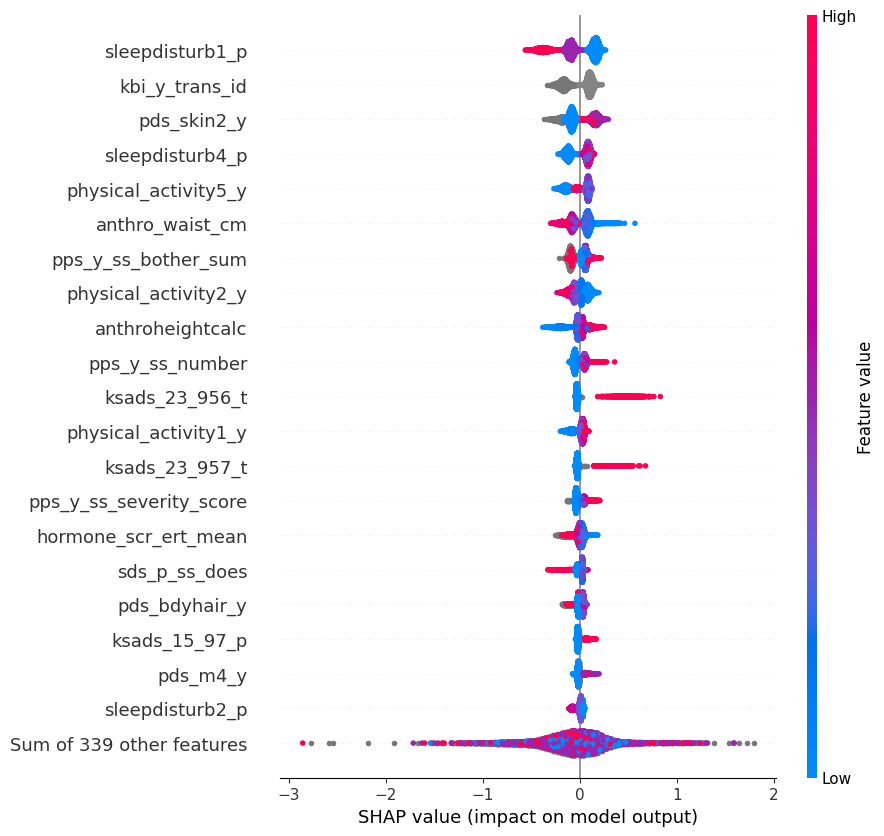


Run 9
8 grid search candidates

Runtime for run 9: 0:07:10.341205

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920610904693604

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168160  7.336640    7.336640
1            kbi_y_trans_id    0.133480  5.823601   13.160242
2               pds_skin2_y    0.125321  5.467625   18.627867
3           sleepdisturb4_p    0.101699  4.437022   23.064888
4      physical_activity5

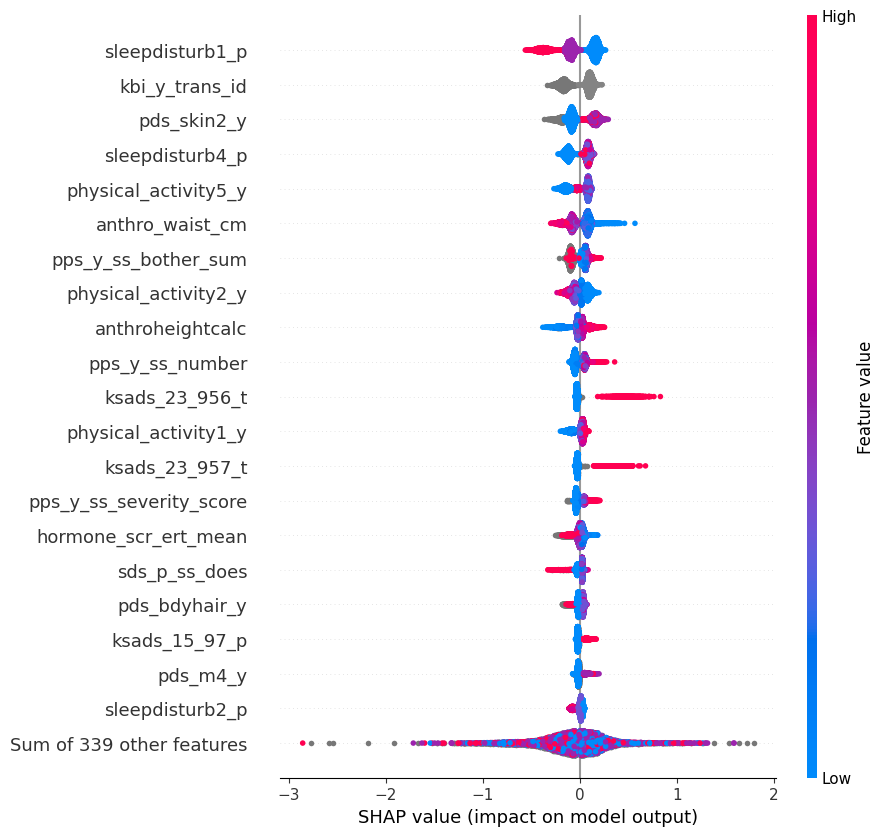


Run 10
8 grid search candidates

Runtime for run 10: 0:07:00.607705

Average ROC AUC score:   0.6741 [0.67582519 0.67971589 0.66480741 0.6590045  0.69122216]
Average accuracy score:  0.8597 [0.85994398 0.85947712 0.85987856 0.85894442 0.86034563]
Average precision score: 0.2857 [0.         0.         0.42857143 0.         1.        ]
Average recall score:    0.0027 [0.         0.         0.01003344 0.         0.00333333]
Average F1 score:        0.0053 [0.         0.         0.01960784 0.         0.00664452]

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 2.2920613288879395

Top 20 features by SHAP value:
                    feature  SHAP value   percent  cumulative
0           sleepdisturb1_p    0.168161  7.336658    7.336658
1            kbi_y_trans_id    0.133481  5.823602   13.160261
2               pds_skin2_y    0.125321  5.467614   18.627874
3           sleepdisturb4_p    0.101699  4.437023   23.064898
4      physical_activit

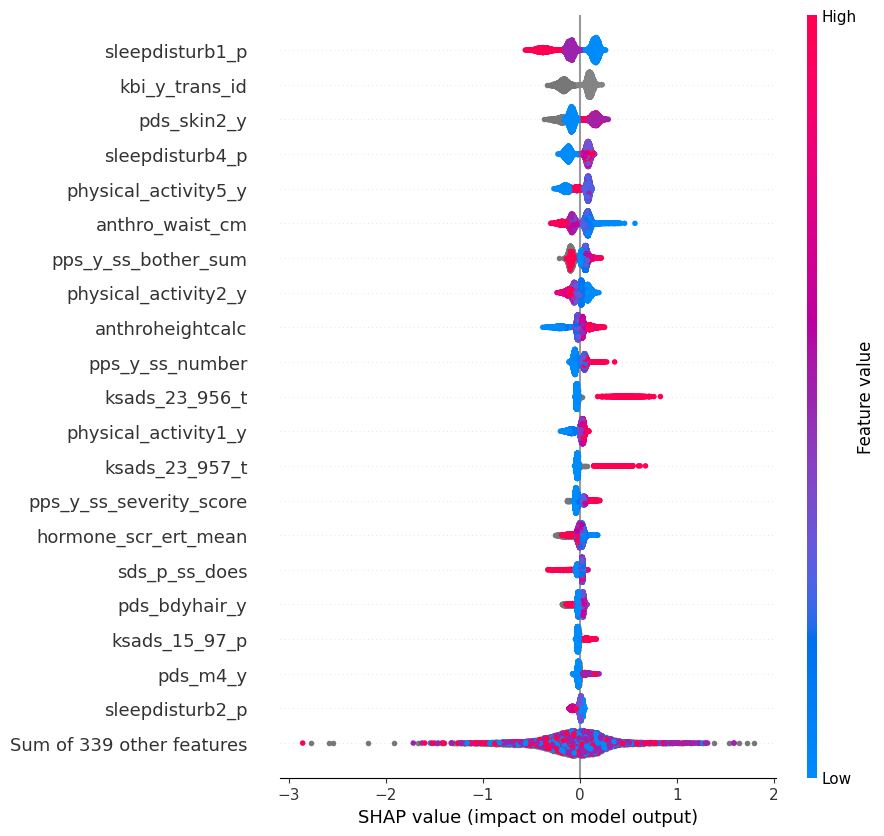


Total runtime for all runs: 2:11:52.970440


In [6]:
def run_nested_cv(num_runs=10):
    overall_start = time()
    
    # define the hyperparameter grid and scoring metrics
    params = {
        'learning_rate': [0.005, 0.01],
        'max_depth': [4, 8],
        'n_estimators': [500, 1000],

    }
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
       
    for run in range(1, num_runs+1):
        print(f"\n{'='*60}\nRun {run}\n{'='*60}")
        run_start = time()
        
        # shuffle the data before assigning family_groups
        perm = np.random.permutation(len(y))
        X_values_shuffled = X_values[perm]
        y_shuffled = y[perm]
        # shuffle the abcd dataframe so we can recompute family_groups from the family id column
        abcd_shuffled = abcd.iloc[perm].reset_index(drop=True)
        
        # recompute family groups from the shuffled 'rel_family_id' column
        d = defaultdict(lambda: len(d))
        family_groups_shuffled = np.array([d[x] for x in abcd_shuffled['rel_family_id']])
        
        # create a new model for each run 
        model = XGBClassifier(
            tree_method='gpu_hist',
            objective='binary:logistic',
            eval_metric='auc',
            colsample_bytree=0.4
        )
        
        # inner loop 
        inner_cv = GroupKFold(n_splits=5)
        inner_cv = inner_cv.get_n_splits(X_values, y, groups=family_groups_shuffled)

        # outer loop
        outer_cv = GroupKFold(n_splits=5)
        outer_cv = outer_cv.get_n_splits(X_values, y, groups=family_groups_shuffled)
        
        # setup GridSearchCV
        gs = GridSearchCV(
            estimator=model, 
            param_grid=params, 
            scoring='roc_auc', 
            cv=inner_cv,
            return_train_score=True,
            verbose=0  
        )
        
        # fit GridSearchCV 
        gs.fit(X_values, y)
        
        # run nested CV using cross_validate
        nested_scores = cross_validate(
            gs,
            X=X_values, 
            y=y, 
            scoring=scoring, 
            cv=outer_cv
        )
        
        # score arrays
        auc = nested_scores['test_roc_auc']
        acc = nested_scores['test_accuracy']
        precision = nested_scores['test_precision']
        recall = nested_scores['test_recall']
        f1 = nested_scores['test_f1']
        
        run_runtime = timedelta(seconds=time() - run_start)
        print(f"{len(ParameterGrid(params))} grid search candidates")
        print(f"\nRuntime for run {run}: {run_runtime}\n")
        print(f'Average ROC AUC score:   {auc.mean():.4f} {auc}')
        print(f'Average accuracy score:  {acc.mean():.4f} {acc}')
        print(f'Average precision score: {precision.mean():.4f} {precision}')
        print(f'Average recall score:    {recall.mean():.4f} {recall}')
        print(f'Average F1 score:        {f1.mean():.4f} {f1}')
        print('\nBest parameters:', gs.best_params_)
        
        # save the GridSearchCV object and nested scores 
        joblib.dump(gs, f'health_gridsearch_run{run}.pkl')
        joblib.dump(nested_scores, f'health_nested_scores_run{run}.pkl')
        
        # obtain model scores from outer folds
        y_scores = cross_val_predict(
            gs, 
            X_values_shuffled, 
            y_shuffled, 
            cv=outer_cv, 
            method='predict_proba', 
            
        )[:, 1]
        # save y_true and y_scores as a CSV
        df_scores = pd.DataFrame({'y_true': y_shuffled, 'y_scores': y_scores})
        df_scores.to_csv(f'health_y_true_y_scores_run{run}.csv', index=False)
        
        # SHAP analysis: create an explainer, compute SHAP values, and display a beeswarm plot
        explainer = shap.Explainer(gs.best_estimator_)
        # use the shuffled features
        X_shuffled = X.iloc[perm].reset_index(drop=True)
        shap_values = explainer(X_shuffled)
        
        # create SHAP ranking dataframe
        features = X_shuffled.columns 
        sv_mean = np.abs(shap_values.values).mean(0)
        sv_rank = pd.DataFrame(list(zip(features, sv_mean)), columns=['feature', 'SHAP value'])
        sv_rank = sv_rank.sort_values(by='SHAP value', ascending=False)
        sv_rank['percent'] = sv_rank['SHAP value'] / sv_rank['SHAP value'].sum() * 100
        sv_rank['cumulative'] = sv_rank['percent'].cumsum()
        sv_rank.reset_index(inplace=True, drop=True)
        sv_rank.to_csv(f'health_shap_ranking_run{run}.csv', index=False)
        
        print(f"\nSum of SHAP values: {sv_rank['SHAP value'].sum()}")
        print("\nTop 20 features by SHAP value:")
        print(sv_rank.head(20))
        
        # display SHAP beeswarm plot
        shap.plots.beeswarm(shap_values, max_display=21)

        
    overall_runtime = timedelta(seconds=time() - overall_start)
    print(f"\n{'='*60}\nTotal runtime for all runs: {overall_runtime}\n{'='*60}")


run_nested_cv(num_runs=10)